# G3c: Return-Blind Factor Preprocessing

## TL;DR

The G2/G3 panels reconcile to 44,728 bond-date rows, 222 signal dates, 846 bonds, and 31 candidate factors. G3c-A freezes cross-sectional scaled-MAD winsorization at 3.0 with 2.5/3.0/3.5 sensitivity. G3c-B has completed valuation- and underlying-equity-family preprocessing. Equity factors are neutralized for point-in-time stock size and CITIC Level-1 industry before standardization. No forward-return field enters this stage.

## Context & Methods

For each factor and signal date, the cross-sectional median and median absolute deviation (MAD) are calculated independently. The clipping interval is `median +/- multiplier * 1.4826 * MAD`; 1.4826 makes MAD comparable to standard deviation under a normal distribution. Missing values remain missing and no bond row is deleted.

### Key Assumptions

- The primary multiplier is 3.0; 2.5 and 3.5 are diagnostics rather than return-selected alternatives.
- Raw factor columns remain available next to `winsorized__*` audit columns.
- Factor-family neutralization is explicit: valuation uses CB-specific controls only where appropriate, while equity factors use stock size and CITIC Level-1 industry.
- Returns, labels, portfolio results, and holdout outcomes are prohibited inputs.

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from cb_quant.notebook_quality import build_lineage_gate

artifact_root = PROJECT_ROOT / 'artifacts' / 'G3C'
audit = json.loads((artifact_root / 'preprocessing_audit_v1.json').read_text())
sensitivity = pd.read_parquet(artifact_root / 'mad_sensitivity_v1.parquet')
valuation_diagnostics = pd.read_parquet(
    artifact_root / 'valuation_preprocessing_diagnostics_v1.parquet'
)
stock_diagnostics = pd.read_parquet(
    artifact_root / 'stock_preprocessing_diagnostics_v1.parquet'
)

## Data Quality Gate

The audit requires exact source keys, unique merged keys, all expected raw and winsorized columns, no forward labels, monotone clipping as the MAD bound widens, and source/configuration fingerprints.

In [2]:
lineage_gate = build_lineage_gate({
    'G3c-A': {'config_sha256': audit['config_sha256']}
})
quality_gate = pd.Series({
    'audit_status_pass': audit['status'] == 'pass',
    'duplicate_keys_zero': audit['duplicate_key_count'] == 0,
    'forward_label_columns_zero': audit['forward_label_column_count'] == 0,
    'missing_output_columns_zero': len(audit['missing_output_columns']) == 0,
    'sensitivity_monotone_all_factors': all(audit['sensitivity_clipping_is_monotone_by_factor'].values()),
    'valuation_and_stock_families_complete': len(audit['completed_g3cb_factors']) == 13,
    'lineage_gate_pass': lineage_gate['status'] == 'pass',
}, name='passed')
assert quality_gate.all()
quality_gate.to_frame()

,passed
audit_status_pass,True
duplicate_keys_zero,True
forward_label_columns_zero,True
missing_output_columns_zero,True
sensitivity_monotone_all_factors,True
valuation_and_stock_families_complete,True
lineage_gate_pass,True


## G3c-B: Underlying-Equity Controls

The nine underlying-equity factors are neutralized against point-in-time log total market capitalization and CITIC Level-1 industry. Market capitalization is matched using only the latest observation on or before the signal date. CB balance, rating, and maturity are intentionally excluded because they are not structural determinants of the underlying-equity signals.

In [3]:
stock_view = stock_diagnostics[[
    'factor_name',
    'processed_coverage',
    'pre_mean_absolute_control_correlation',
    'post_mean_absolute_control_correlation',
    'winsorized_to_processed_rank_correlation',
]].sort_values('winsorized_to_processed_rank_correlation').copy()
assert stock_view['post_mean_absolute_control_correlation'].max() < 1e-10
stock_view

,factor_name,processed_coverage,pre_mean_absolute_control_correlation,post_mean_absolute_control_correlation,winsorized_to_processed_rank_correlation
7,stock_amihud_20d,0.980795,0.111534,1.008136e-15,0.377203
1,stock_return_10d,0.982830,0.089688,3.586283e-16,0.760696
0,stock_return_5d,0.984506,0.089423,4.011979e-16,0.760729
3,stock_volatility_20d,0.980795,0.089389,4.187676e-16,0.766633
2,stock_return_20d,0.978984,0.089540,3.964886e-16,0.768548
5,stock_price_to_high_20d,0.980795,0.089593,1.790997e-15,0.773296
6,stock_percent_b_20d,0.980795,0.091762,4.226789e-16,0.781978
4,stock_rsi_20d,0.980795,0.091301,5.191697e-16,0.786513
8,stock_mfi_20d,0.980661,0.086566,5.324392e-16,0.814152


## G3c-B: Valuation-Family Controls

Conversion premium and double-low retain their complete valuation meaning and therefore receive no neutralization. Same-parity relative premium already controls parity by construction; its residual is additionally neutralized against log remaining balance, rating categories, and remaining maturity. `parity_value_score` is processed identically as a direction-reversed audit counterpart and will not coexist with relative premium in the final redundancy-filtered model.

In [4]:
valuation_view = valuation_diagnostics[[
    'factor_name',
    'neutralized',
    'numeric_controls',
    'categorical_controls',
    'processed_coverage',
    'pre_mean_absolute_control_correlation',
    'post_mean_absolute_control_correlation',
    'winsorized_to_processed_rank_correlation',
]].copy()
assert valuation_view.loc[valuation_view['neutralized'], 'post_mean_absolute_control_correlation'].max() < 1e-10
valuation_view

,factor_name,neutralized,numeric_controls,categorical_controls,processed_coverage,pre_mean_absolute_control_correlation,post_mean_absolute_control_correlation,winsorized_to_processed_rank_correlation
0,conversion_premium,False,,,1.000000,NaN,NaN,1.000000
1,double_low,False,,,1.000000,NaN,NaN,1.000000
2,relative_premium_to_parity_median,True,"log_remaining_balance,remaining_maturity_years",rating,0.991169,0.122291,4.107625e-16,0.911945
3,parity_value_score,True,"log_remaining_balance,remaining_maturity_years",rating,0.991169,0.122291,4.107625e-16,0.911945


## Results

The table below summarizes the primary 3.0-MAD treatment. `clipped_rate` measures how often a raw observation is capped, while rank correlation checks whether cross-sectional ordering is preserved.

In [5]:
headline = pd.Series({
    'Rows': audit['row_count'],
    'Signal dates': audit['signal_date_count'],
    'Bonds': audit['bond_count'],
    'Factors': audit['factor_count'],
    'Primary MAD multiplier': audit['primary_mad_multiplier'],
}, name='Observed value')
display(headline.to_frame())
primary = sensitivity.loc[sensitivity['mad_multiplier'].eq(3.0)].copy()
primary = primary.sort_values('clipped_rate', ascending=False)
primary[['factor_name', 'observations', 'clipped_count', 'clipped_rate', 'mean_cross_sectional_rank_correlation']].head(12)

,Observed value
Rows,44728.0
Signal dates,222.0
Bonds,846.0
Factors,31.0
Primary MAD multiplier,3.0


,factor_name,observations,clipped_count,clipped_rate,mean_cross_sectional_rank_correlation
61,parity_value_score,44333,4100,0.092482,0.999674
64,relative_premium_to_parity_median,44333,4100,0.092482,0.999674
16,cb_daily_turnover,44727,3619,0.080913,0.999553
58,double_low,44728,3361,0.075143,0.999711
4,cb_abnormal_turnover_60d,42708,3062,0.071696,0.999714
1,cb_abnormal_turnover_20d,44601,3192,0.071568,0.999739
55,conversion_premium,44728,3037,0.067899,0.999690
67,stock_amihud_20d,44671,2640,0.059099,0.999811
10,cb_close_to_vwap,44727,2100,0.046952,0.999930
7,cb_amihud_20d,44556,1993,0.044730,0.999751


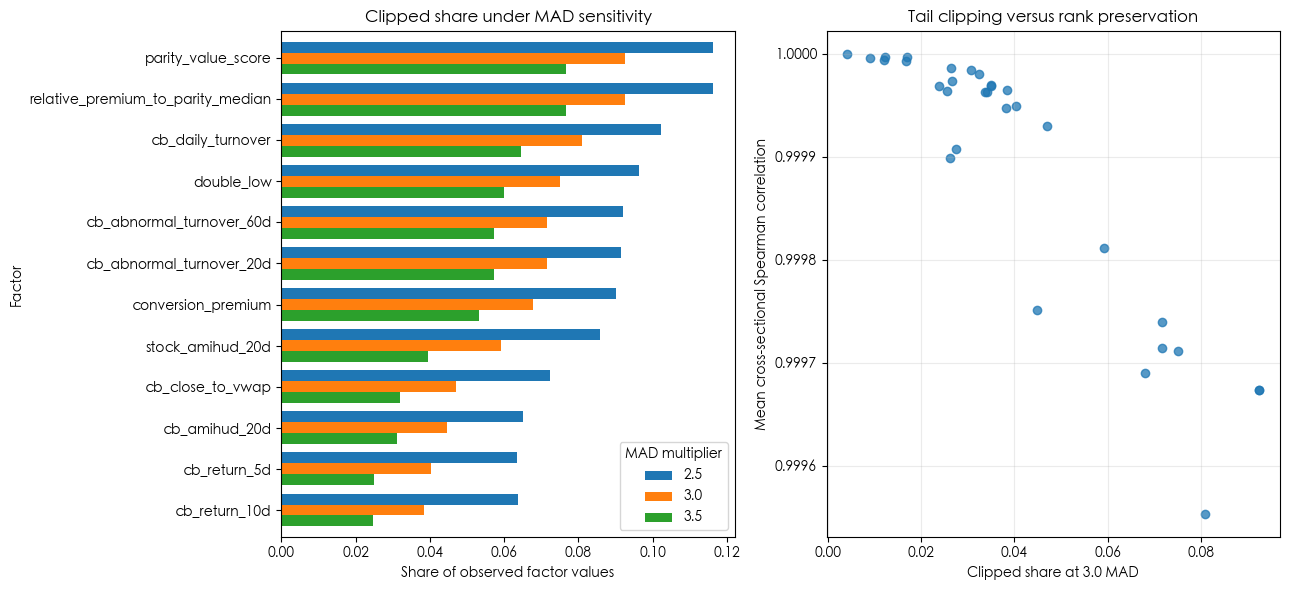

In [6]:
top_factors = primary.head(12)['factor_name'].tolist()
plot_data = sensitivity.loc[sensitivity['factor_name'].isin(top_factors)].copy()
pivot = plot_data.pivot(index='factor_name', columns='mad_multiplier', values='clipped_rate').loc[top_factors]

figure, axes = plt.subplots(1, 2, figsize=(13, 6))
pivot.plot(kind='barh', ax=axes[0], width=0.8)
axes[0].invert_yaxis()
axes[0].set_title('Clipped share under MAD sensitivity')
axes[0].set_xlabel('Share of observed factor values')
axes[0].set_ylabel('Factor')
axes[0].legend(title='MAD multiplier')

ranked = primary.sort_values('mean_cross_sectional_rank_correlation')
axes[1].scatter(ranked['clipped_rate'], ranked['mean_cross_sectional_rank_correlation'], alpha=0.75)
axes[1].set_title('Tail clipping versus rank preservation')
axes[1].set_xlabel('Clipped share at 3.0 MAD')
axes[1].set_ylabel('Mean cross-sectional Spearman correlation')
axes[1].grid(alpha=0.25)
figure.tight_layout()
plt.show()

## Takeaways

- The merged panel preserves all 44,728 investable observations and contains no duplicate keys or forward labels.
- The 3.0-MAD setting clips about 4.0% of observations for the average factor; the maximum factor-level rate is about 9.25%.
- Same-parity relative valuation, turnover, double-low, conversion premium, and illiquidity variables have the heaviest tails.
- Mean cross-sectional rank correlations remain above 0.9995 at the primary setting, so treatment changes magnitudes mainly in the tails rather than broad rankings.
- Valuation-family preprocessing is complete: absolute valuation structure is preserved, while same-parity relative value is neutralized for log balance, rating, and maturity.
- Same-parity residual control exposure falls from about 0.122 to numerical zero, while the processed factor retains about 0.912 rank correlation with its winsorized input.
- The two same-parity factors are direction-reversed duplicates and must not both enter the final model.
- Point-in-time stock market capitalization covers about 99.97% of rows; joint market-cap and CITIC Level-1 industry coverage is about 99.30%.
- Equity-factor control exposure falls to numerical zero. Most processed factors retain 0.76-0.81 rank correlation with their winsorized inputs, while stock Amihud retains 0.377, indicating substantial original stock-size and industry loading.
- G3c-B must still decide neutralization for the stock-bond linkage and convertible-bond trading families.